In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn import metrics
from sklearn import model_selection
from sklearn import preprocessing
np.random.seed(7)

In [3]:
data = pd.read_excel("career_dataset_large.xlsx")

In [4]:
data.head()

,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career
0,Bachelor's,Finance,"Counseling, MS Office, Machine Learning",Tally ERP,67,Business Analyst
1,Intermediate,Science,"Accounting, MS Office",AWS Certified,67,Software Engineer
2,Master's,Business,"Accounting, SQL, Data Analysis",Mental Health Basics,90,Financial Analyst
3,Bachelor's,Computer Science,Communication,NaN,75,Clerk
4,Matric,Business,Data Analysis,Tally ERP,83,Sales Assistant


In [5]:
data.describe()

,CGPA/Percentage
count,5000.000000
mean,77.479800
std,10.396288
min,60.000000
25%,68.000000
50%,77.000000
75%,87.000000
max,95.000000


(array([1021.,    0.,  973.,    0.,    0., 1028.,    0., 1014.,    0.,
         964.]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

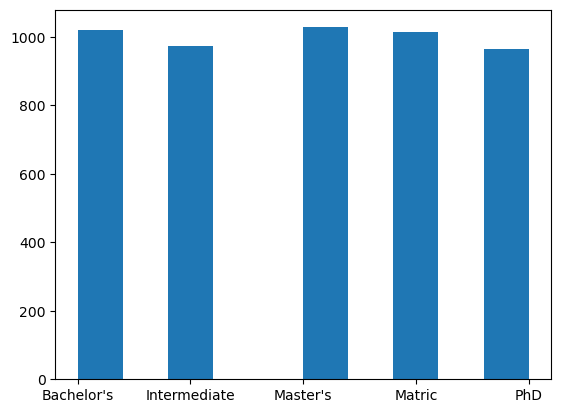

In [6]:
plt.hist(data['Education Level'].values)

In [7]:
columns_to_binarize = [ 0, 1, 2, 3]
binary_to_index = {}

for column_index in columns_to_binarize:
    for value in data.iloc[:, column_index]:
        if pd.notna(value):
            for splits in str(value).split(', '):
                binary_to_index[splits] = column_index
binary_to_index

{"Bachelor's": 0,
 'Intermediate': 0,
 "Master's": 0,
 'Matric': 0,
 'PhD': 0,
 'Finance': 1,
 'Science': 1,
 'Business': 1,
 'Computer Science': 1,
 'Arts': 1,
 'Psychology': 1,
 'Commerce': 1,
 'Engineering': 1,
 'Counseling': 2,
 'MS Office': 2,
 'Machine Learning': 2,
 'Accounting': 2,
 'SQL': 2,
 'Data Analysis': 2,
 'Communication': 2,
 'Financial Analysis': 2,
 'Python': 2,
 'Marketing': 2,
 'Tally ERP': 3,
 'AWS Certified': 3,
 'Mental Health Basics': 3,
 'Digital Marketing': 3,
 'CFA Level 1': 3,
 'Creative Writing': 3,
 'Google Data Analytics': 3}

In [8]:
feature_names = list(binary_to_index.keys()) + ['CGPA/Percentage']
feature_names

["Bachelor's",
 'Intermediate',
 "Master's",
 'Matric',
 'PhD',
 'Finance',
 'Science',
 'Business',
 'Computer Science',
 'Arts',
 'Psychology',
 'Commerce',
 'Engineering',
 'Counseling',
 'MS Office',
 'Machine Learning',
 'Accounting',
 'SQL',
 'Data Analysis',
 'Communication',
 'Financial Analysis',
 'Python',
 'Marketing',
 'Tally ERP',
 'AWS Certified',
 'Mental Health Basics',
 'Digital Marketing',
 'CFA Level 1',
 'Creative Writing',
 'Google Data Analytics',
 'CGPA/Percentage']

In [9]:
target = 'Recommended Career'

In [10]:
x = pd.DataFrame(np.zeros( (len(data), len(feature_names)), dtype=int), columns = feature_names)

In [11]:
x.shape

(5000, 31)

In [12]:
for index in range(len(feature_names)):
    feature_name = feature_names[index]
    if feature_name not in binary_to_index:
        x[feature_name] = data[feature_name]
        continue
        
    column_index = binary_to_index[feature_name]

    for row in range(len(data)):
        value = data.iloc[row, column_index]
        if pd.notna(value):
            split = value.split(', ')
            x.iloc[row, index] = int(feature_name in split)

x

,Bachelor's,Intermediate,Master's,Matric,PhD,Finance,Science,Business,Computer Science,Arts,...,Python,Marketing,Tally ERP,AWS Certified,Mental Health Basics,Digital Marketing,CFA Level 1,Creative Writing,Google Data Analytics,CGPA/Percentage
0,1,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,67
1,0,1,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,67
2,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,90
3,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,75
4,0,0,0,1,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0,0,0,1,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,90
4996,0,0,1,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,1,0,92
4997,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,63
4998,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,83


In [13]:
target_names = data[target].unique()

y = data[target]

label_encoder = preprocessing.LabelEncoder()
y_encoded = label_encoder.fit_transform( data[target] )

y_encoded

array([ 0, 11,  3, ...,  3, 11,  1], shape=(5000,))

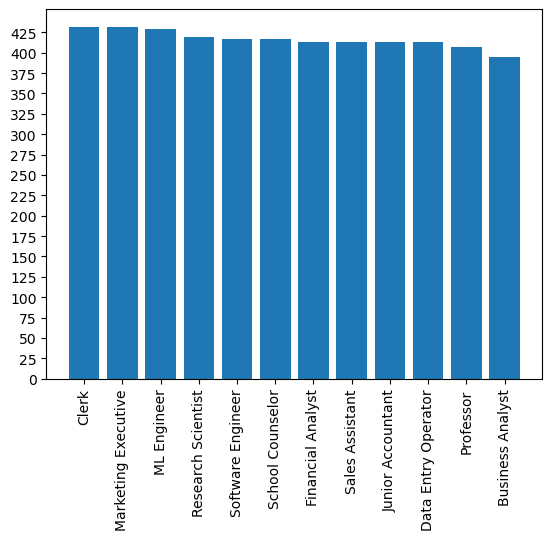

In [72]:
class_counts = y.value_counts()

plt.bar(range(0,12), class_counts.values)
plt.xticks(range(0, 12), class_counts.index, rotation='vertical')
plt.yticks(range(0, 450, 25))
plt.show()

In [70]:
y.value_counts()

Recommended Career
Clerk                  432
Marketing Executive    432
ML Engineer            429
Research Scientist     419
Software Engineer      417
School Counselor       417
Financial Analyst      413
Sales Assistant        413
Junior Accountant      413
Data Entry Operator    413
Professor              407
Business Analyst       395
Name: count, dtype: int64

In [14]:
correlation_matrix = x.corr()

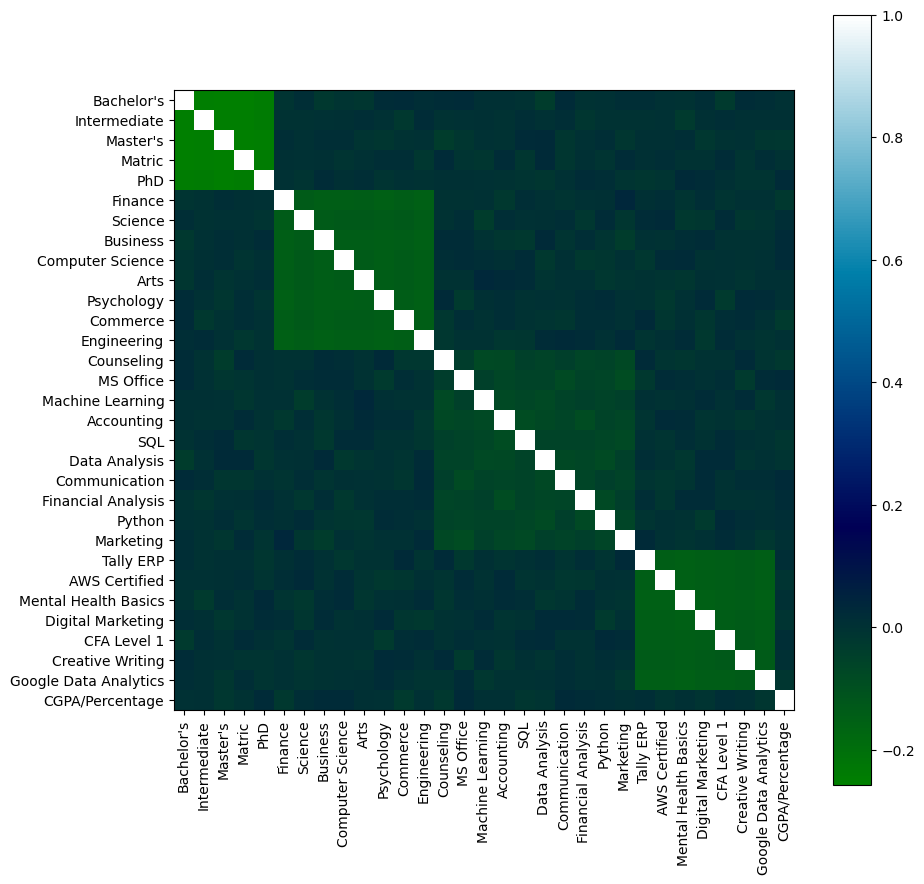

In [15]:
number_of_features = len(feature_names)

plt.figure(figsize=(10, 10))
plt.xticks(range(number_of_features), feature_names, rotation='vertical')
plt.yticks(range(number_of_features), feature_names)
plt.imshow(correlation_matrix, cmap='ocean')
plt.colorbar()
plt.show()

In [16]:
coefs = []

for feature_name in feature_names:
    column = x[feature_name]
    coefs.append(np.corrcoef(column, y_encoded)[0][1])

coefs

[np.float64(-0.008072675208048082),
 np.float64(-0.024586745429406184),
 np.float64(0.008700106698753656),
 np.float64(0.0222205728460023),
 np.float64(0.0013620384855234035),
 np.float64(-0.004390854016676729),
 np.float64(0.012292096447667402),
 np.float64(0.0017941139669852841),
 np.float64(-0.017235983047451876),
 np.float64(0.006358464402055807),
 np.float64(-0.013688086941928874),
 np.float64(-0.009090626105256457),
 np.float64(0.02390563939847733),
 np.float64(-0.0005889260843220469),
 np.float64(0.002791966341985269),
 np.float64(-0.0075725919768174525),
 np.float64(0.0023355139511453548),
 np.float64(0.01682037488660058),
 np.float64(-0.014325093947092613),
 np.float64(-0.0018875251683660502),
 np.float64(-0.0009698947684498366),
 np.float64(0.020688347690816195),
 np.float64(0.004651654194087493),
 np.float64(-0.00935024052363462),
 np.float64(0.01903723161286763),
 np.float64(0.0018352779344389099),
 np.float64(0.017580032007328075),
 np.float64(-0.012300513848297492),
 np.f

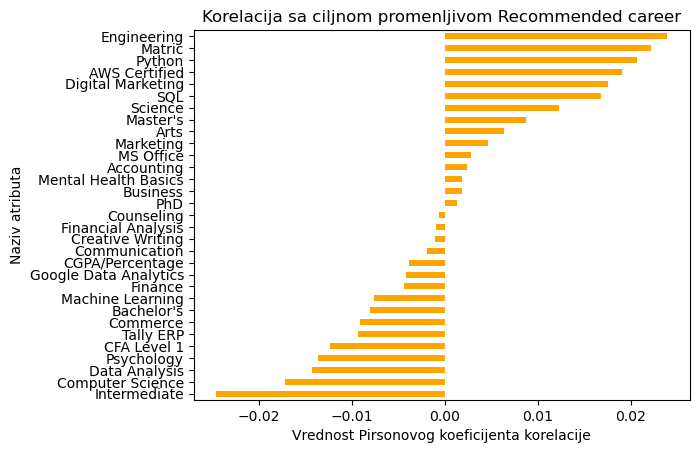

In [17]:
corrcoefs_for_plot = pd.Series(coefs, index=feature_names)
corrcoefs_for_plot.sort_values(inplace=True)

corrcoefs_for_plot.plot(kind='barh', color='orange')
plt.title('Korelacija sa ciljnom promenljivom Recommended career')
plt.xlabel('Vrednost Pirsonovog koeficijenta korelacije')
plt.ylabel('Naziv atributa')
plt.show()

In [18]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(x, y_encoded, test_size=0.33, stratify=y, random_state = 7)
scaler = preprocessing.StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [19]:
model = linear_model.LogisticRegression()

In [20]:
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
y_test_predicted = model.predict(x_test)

In [22]:
print(y_test_predicted)

[ 0 10  1 ...  1  3  7]


In [23]:
y_test_predicted_strings = label_encoder.inverse_transform(y_test_predicted)
y_test_predicted_strings

array(['Business Analyst', 'School Counselor', 'Clerk', ..., 'Clerk',
       'Financial Analyst', 'Professor'], shape=(1650,), dtype=object)

In [24]:
model.score(x_train, y_train)

0.1417910447761194

In [25]:
model.score(x_test, y_test)

0.08121212121212121

In [26]:
metrics.confusion_matrix(y_test, y_test_predicted)

array([[ 4, 17, 10,  7, 11,  5, 20,  7, 19,  7, 17,  6],
       [11, 25, 10,  5, 10,  7, 17, 10, 13,  5, 27,  3],
       [ 8, 26, 14, 10, 13,  5, 12,  3, 16,  7, 19,  3],
       [10, 19, 13,  9,  8,  3, 13,  7, 17,  9, 17, 11],
       [ 8, 23, 12,  8, 10,  6, 17,  7, 14,  5, 23,  3],
       [10, 24, 10,  5,  7,  4, 13,  9, 19, 11, 17, 13],
       [12, 15, 10, 10,  6, 11, 16, 10, 12, 13, 15, 13],
       [ 7, 23, 10,  7, 12,  3, 22,  8, 18,  9, 11,  4],
       [ 8, 24, 10,  9, 10,  6, 17,  5, 20, 10, 13,  6],
       [ 6, 13, 17,  5,  7,  2, 22,  9, 22,  5, 20,  8],
       [10, 20, 12,  6,  7,  9, 17,  9, 20, 10, 13,  5],
       [ 4, 17, 11,  9, 11, 10, 13,  8, 19, 12, 18,  6]])

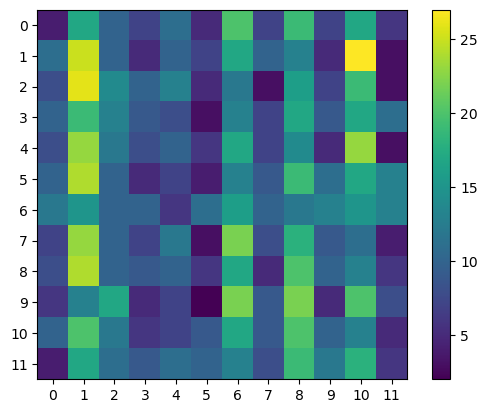

In [31]:
plt.imshow(metrics.confusion_matrix(y_test, y_test_predicted))
plt.xticks(range(0,  12))
plt.yticks(range(0,  12))
plt.colorbar()

In [27]:
print(metrics.classification_report(y_test, y_test_predicted))

              precision    recall  f1-score   support

           0       0.04      0.03      0.04       130
           1       0.10      0.17      0.13       143
           2       0.10      0.10      0.10       136
           3       0.10      0.07      0.08       136
           4       0.09      0.07      0.08       136
           5       0.06      0.03      0.04       142
           6       0.08      0.11      0.09       143
           7       0.09      0.06      0.07       134
           8       0.10      0.14      0.12       138
           9       0.05      0.04      0.04       136
          10       0.06      0.09      0.07       138
          11       0.07      0.04      0.05       138

    accuracy                           0.08      1650
   macro avg       0.08      0.08      0.08      1650
weighted avg       0.08      0.08      0.08      1650



In [89]:
metrics.accuracy_score(y_test, y_test_predicted)

0.08121212121212121

In [86]:
model1 = linear_model.LogisticRegression(max_iter=1000)

In [87]:
scores = model_selection.cross_val_score(model1, x, y, cv=10, scoring='accuracy')
scores

array([0.102, 0.08 , 0.096, 0.088, 0.112, 0.066, 0.092, 0.082, 0.09 ,
       0.08 ])

In [88]:
scores.mean()

np.float64(0.08879999999999999)